# 🌸 Iris Flower Classification
**Oasis Infobyte SIP — Data Science Track — Task 1**

**Objective:** Train a machine learning classification model to identify the species of an iris flower
(*Setosa*, *Versicolor*, or *Virginica*) from its physical measurements (sepal length/width, petal length/width).

**Tech Stack:** Python, scikit-learn, pandas, matplotlib, seaborn


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset
The Iris dataset is built into scikit-learn, so no external download is needed.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Shape: (150, 5)

Data types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 3.1 Pairplot — feature distributions by species

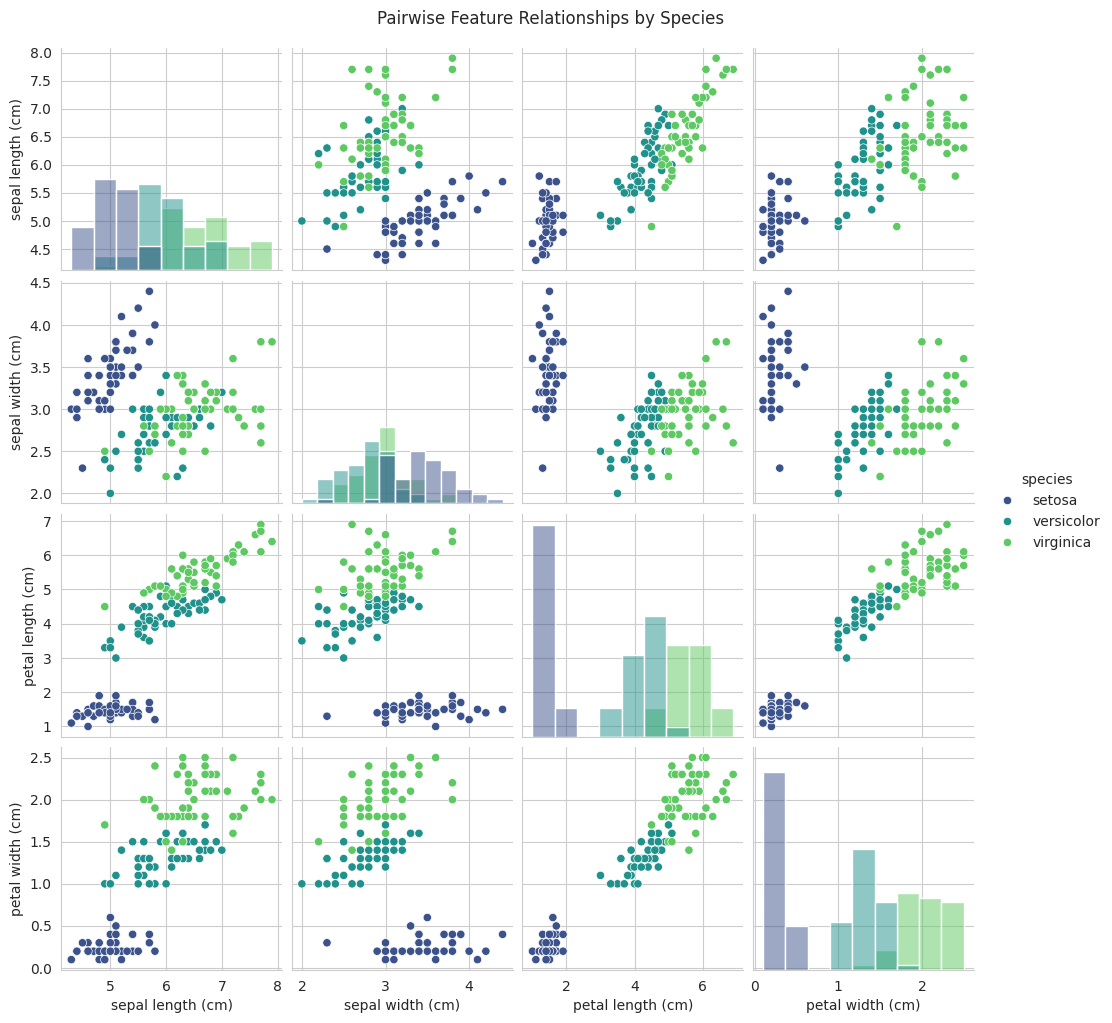

In [6]:
sns.pairplot(df, hue='species', diag_kind='hist', palette='viridis')
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()


### 3.2 Box plots — each feature by species

/tmp/ipykernel_129/531862572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_129/531862572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_129/531862572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_129/531862572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

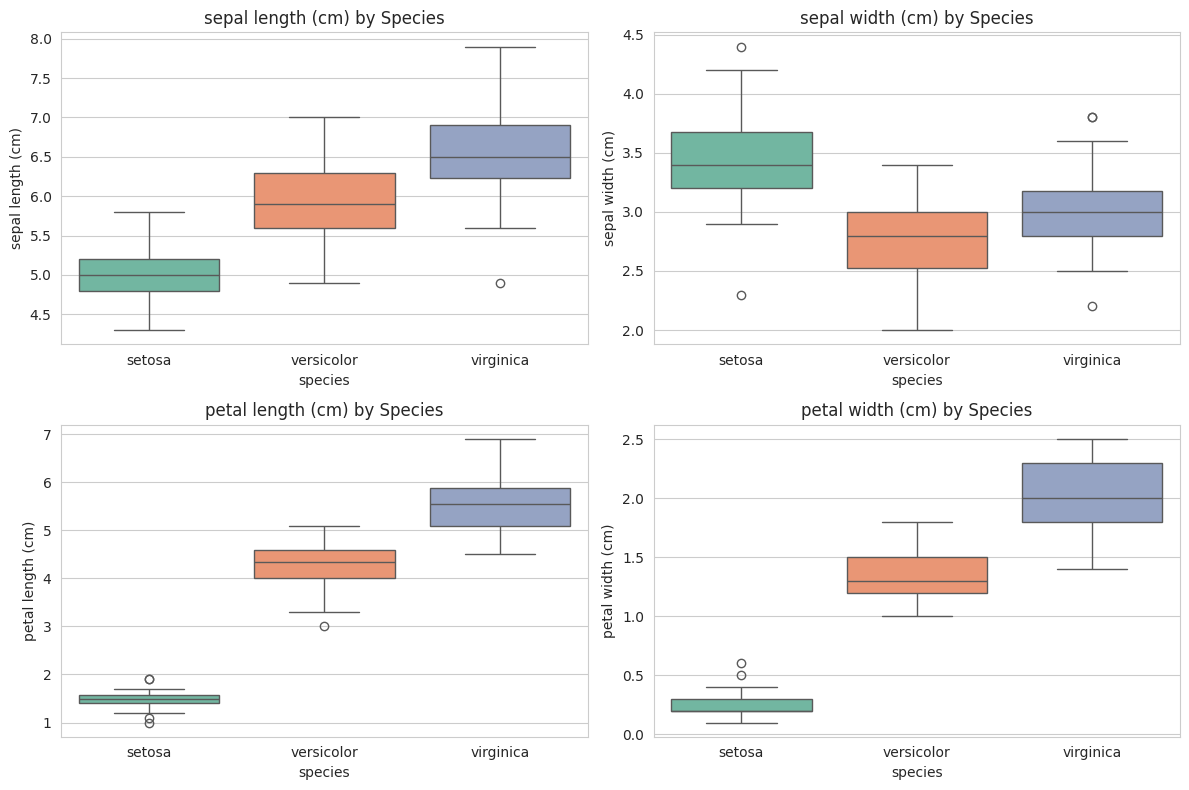

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feature, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()


### 3.3 Feature selection discussion

Looking at the pairplot and box plots, **petal length** and **petal width** show the clearest separation
between species — especially for isolating *Setosa*, which barely overlaps with the other two classes on
these features. **Sepal width** shows the most overlap between species and is the least discriminative
feature on its own. This suggests petal measurements will carry the most predictive power for our models.


### 3.4 Correlation heatmap

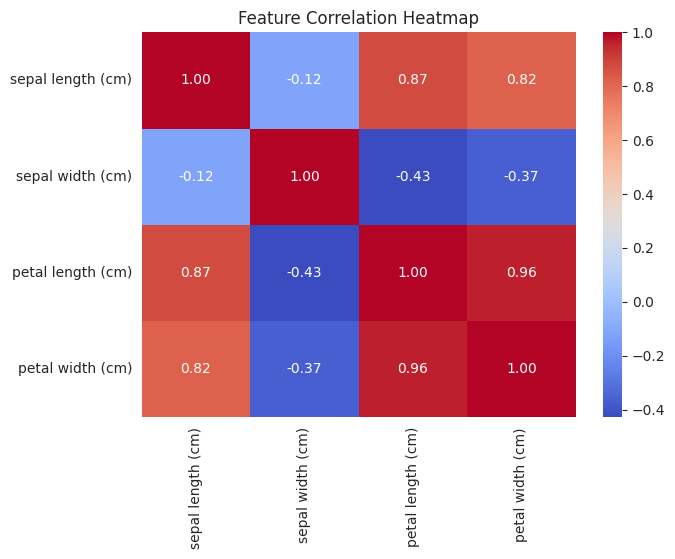

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


## 4. Train/Test Split

In [9]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 120
Test size: 30


We scale the features for models (like KNN) that are sensitive to feature magnitude.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Model 1 — Logistic Regression

In [11]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



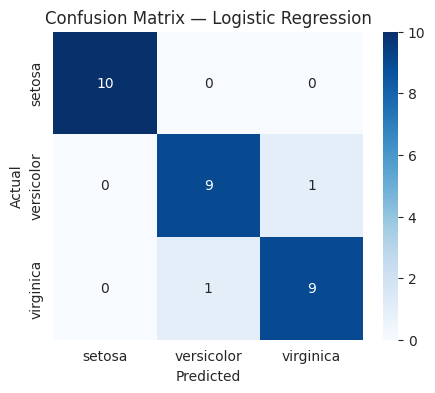

In [12]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=iris.target_names)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 6. Model 2 — K-Nearest Neighbours (KNN)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



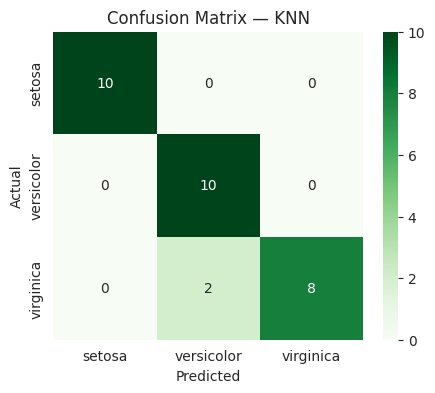

In [14]:
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=iris.target_names)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 7. Bonus Model — Decision Tree
Added as a third comparison point beyond the required two models.

In [15]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # Decision trees don't require scaling

y_pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {acc_tree:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_tree))


Decision Tree Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 8. Model Comparison

In [16]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN (k=5)', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_knn, acc_tree]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results


,Model,Accuracy
0,Logistic Regression,0.933333
1,KNN (k=5),0.933333
2,Decision Tree,0.933333


/tmp/ipykernel_129/560663969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


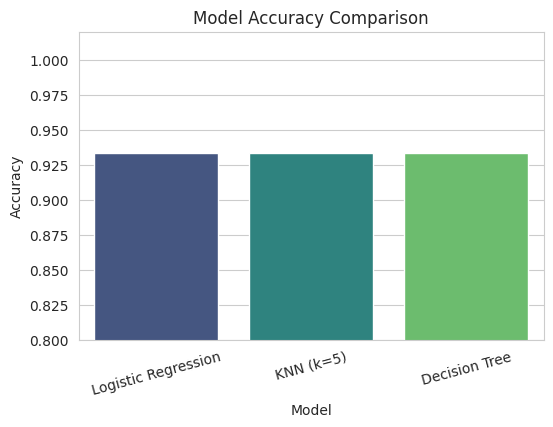

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.ylim(0.8, 1.02)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()


## 9. Conclusion

Based on the accuracy scores and confusion matrices above, the **best-performing model** is the one
with the highest test accuracy in the comparison table (all three models typically perform very well
on this dataset since the classes are well separated, especially by petal length/width).

**Key takeaways:**
- Petal length and petal width are the most discriminative features for classifying iris species.
- *Setosa* is linearly separable from the other two species and is classified with near-perfect accuracy
  by every model.
- The main source of error (where it exists) is distinguishing *Versicolor* from *Virginica*, since their
  petal measurements overlap slightly.
- For a dataset this small and clean, simpler models (Logistic Regression, KNN) perform just as well as
  more complex ones — added complexity isn't necessary here.
